# Load the Architecture Model
First the architecture is loaded for analysis.

In [1]:
import capellambse.decl
resources = {
    "eRod_A_V_202406": "eRod_A_V_202406/eRod_A_V_202406",
}
path_to_model = "../eRod_A_V_202406.aird"
model = capellambse.MelodyModel(path_to_model, resources=resources)
import capellambse_helper

from IPython import display as diag_display
display(type(model.la.all_component_exchanges[0]).__name__)

Ignoring file of unknown type, loaded model may be incomplete: eRod_Autonomous_Vehicle_202406.traceability
Ignoring file of unknown type, loaded model may be incomplete: eRod_A_V_202406.traceability


'ComponentExchange'

In [2]:
import Open_AI_RAG_manager

# Generate embeddings for all objects
model_embedding_manager = Open_AI_RAG_manager.EmbeddingManager()

embedding_file = "embeddings.json" 
model_embedding_manager.set_files( path_to_model , embedding_file)

model_embedding_manager.create_model_embeddings(model)

# Example query and filters
query = input("Enter query for objects to be analyzed?")

# Filter and rank objects
ranked_objects = model_embedding_manager.find_similar_objects(query )

# Display the ranked objects
print("\nThis is a list of ranked Objects Based on Query:")
for i, (obj, similarity) in enumerate(ranked_objects):
    print(f"Index: {i}, Name: {obj['name']}, Similarity: {similarity:.2f}, Type: {obj['type']}")

# Display the content of the YAML file
selected_indices = input("Enter the indices of the selected objects (comma-separated): ")
selected_indices = [int(i.strip()) for i in selected_indices.split(",")]

OpenAI API Key retrieved successfully.
Loading embeddings


Enter query for objects to be analyzed? Master Braking Cylinder



This is a list of ranked Objects Based on Query:
Index: 0, Name: Brake Master Cylinder, Similarity: 0.66, Type: LogicalComponent
Index: 1, Name: Manual Braking, Similarity: 0.64, Type: Capability
Index: 2, Name: Manual Braking, Similarity: 0.62, Type: FunctionalChain
Index: 3, Name: Apply Brake, Similarity: 0.61, Type: SystemFunction
Index: 4, Name: Receive Brake Press, Similarity: 0.59, Type: SystemFunction
Index: 5, Name: Brakes, Similarity: 0.58, Type: PhysicalComponent
Index: 6, Name: Hand Brake, Similarity: 0.56, Type: PhysicalComponent
Index: 7, Name: Brake Boosster, Similarity: 0.56, Type: PhysicalComponent
Index: 8, Name: Brake Fluid Container, Similarity: 0.55, Type: PhysicalComponent
Index: 9, Name: Brake Calipers, Similarity: 0.55, Type: LogicalComponent


Enter the indices of the selected objects (comma-separated):  0


# Architecture elements selected are depicted below. 
Below is a rendered depiction of the elements in the model. 

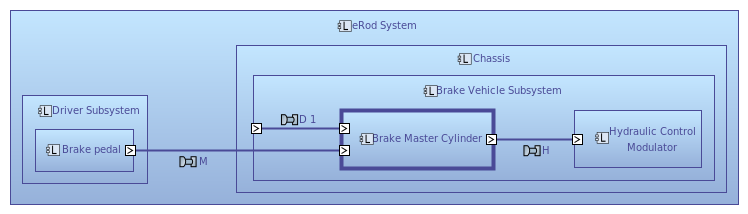

In [3]:
#Workflow
import capellambse_yaml_manager
yaml_handler = capellambse_yaml_manager.CapellaYAMLHandler()

# Extract selected objects
selected_objects = [ranked_objects[i][0] for i in selected_indices]

#Generate YAML for the logical component and append to the file
for object in  selected_objects : 
    obj = model.search(object["type"]).by_uuid(object["uuid"])
    display(obj.context_diagram)
   

#Generate YAML for the logical component and append to the file
for object in  selected_objects :  
    yaml_handler.generate_yaml( model.search(object["type"]).by_uuid(object["uuid"]))

yaml_handler.generate_yaml_referenced_objects()
#yaml_handler.display()

yaml_handler.write_output_file()

In [4]:
prompt = """
Please analyze the YAML file and display the result as .html specifically provide insights on:
1. The purpose of the component.
2. Any components that make it up.
2. A list of allocated functions and their potential roles.
3. How the ports relate to the functions.
4. Suggestions for improving the component description.
5. Create a tabular table with columns for the component and its ports and the port interfaces, the interface souce and the interface target.

Please format the analysis in .html suitable for Juypter Notbook display operation.
"""

In [5]:
import os
from openai import OpenAI
from IPython.core.display import HTML
from IPython.display import display, clear_output, Markdown

# Display Prompt
display(Markdown(f"# The architecture is analyzed by ChatGPT with following prompt.\n {prompt}\n"))

# Step 1: Get YAML content
yaml_content = yaml_handler.get_yaml_content()

# Step 2: Invoke ChatGPT for analysis
analyzer = Open_AI_RAG_manager.ChatGPTAnalyzer(yaml_content)
analyzer.add_prompt(prompt)
chatgpt_response = analyzer.get_response()

# Step 3: Display the response in the notebook
#print("ChatGPT Analysis:\n")
display(Markdown(f"\n\n**ChatGPT Analysis:**\n"))
#print(chatgpt_response)
display(HTML(chatgpt_response))


# The architecture is analyzed by ChatGPT with following prompt.
 
Please analyze the YAML file and display the result as .html specifically provide insights on:
1. The purpose of the component.
2. Any components that make it up.
2. A list of allocated functions and their potential roles.
3. How the ports relate to the functions.
4. Suggestions for improving the component description.
5. Create a tabular table with columns for the component and its ports and the port interfaces, the interface souce and the interface target.

Please format the analysis in .html suitable for Juypter Notbook display operation.



OpenAI API Key retrieved successfully.




**ChatGPT Analysis:**


In [6]:
Open_AI_RAG_manager.interactive_chat(analyzer)

Starting interactive chat...


Enter your prompt (or type 'exit' to quit): exit


Exiting...
